### 1. Setup and Clone Repository
First, we clone the project repository into the Colab environment and navigate into the directory. 

In [ ]:
REPO_URL = "https://github.com/YOUR_USERNAME/YOUR_REPO_NAME.git"
REPO_NAME = REPO_URL.split("/")[-1].replace(".git", "")

!git clone $REPO_URL
%cd $REPO_NAME

### 2. Install Required Libraries

In [ ]:
import sys
!{sys.executable} -m pip install -U numpy pandas matplotlib astropy tqdm

### 3. Compile the C++ and CUDA Extensions
Colab already has the CUDA toolkit and `nvcc` in its PATH. We just need to run your makefile to build both the CPU fallback (`accel`, `simulator`) and the GPU extensions (`accel_gpu`, `simulator_gpu`).

In [ ]:
!make clean
!make all

# Verify the extensions built successfully
!ls -l *.so

### 4. Run the Full Program on CPU
We can force the dispatcher in `accel.py` to use the CPU backend by passing the `NBODY_FORCE_CPU=1` environment variable. This is great for benchmarking the baseline speed.

In [4]:
# Run the simulation strictly on the CPU
!NBODY_FORCE_CPU=1 python3 proj3.py \
  --particles 5 \
  --total-mass-msol 1e-18 \
  --sphere-radius-au 1e-3 \
  --collision-radius-factor 0.01 \
  --dt-years 0.5 \
  --max-years 100000 \
  --n-simulations 1 \
  --chunk-steps 10000

Compute backend: CPU (forced)
Compute units: 16
N-body simulation
Particles: 5
Total mass: 1.000000e-18 solar masses
Particle mass: 2.000000e-19 solar masses
Initial sphere radius: 1.000000e-03 AU
Collision radius: 1.000000e-05 AU
Timestep: 0.5000 years
Maximum steps: 200000
Simulation duration: 100000.0 years
Number of simulations: 1

Running first simulation...

Simulation 1/1
Simulation 1: 581500 steps | , 99952.8 yrMaximum steps reached without achieving virial equilibrium
Simulation 1: 581500 steps | , 99952.8 yr
Writing chunks (sim 1): 100%|████████████████| 59/59 [00:05<00:00, 10.92chunk/s]
Combining 59 chunks into single HDU for simulation 1...
Cleaning up temporary chunks for simulation 1...
Simulation 1 complete

Starting visualization of simulation 1...
Close the visualization window to continue
Loading simulation metadata from FITS...
Building time index for simulation 1...
Found 581595 time points
Preloading initial frames...
Preloaded 5 frames
Figure(1400x800)

Visualizat

### 5. Run the Full Program on GPU
By default, the backend dispatcher will attempt to use the GPU extensions we compiled in Step 3. This will leverage Colab's hardware for the O(N^2) force calculations and the integration loop.

In [11]:
# Run the simulation utilizing the CUDA backend
!python3 nbody.py \
  --particles 5 \
  --total-mass-msol 1e-18 \
  --sphere-radius-au 1e-3 \
  --collision-radius-factor 0.01 \
  --dt-years 0.5 \
  --max-years 300000 \
  --n-simulations 1 \
  --chunk-steps 10000

Compute backend: GPU
Compute units: 30
N-body simulation
Particles: 5
Total mass: 1.000000e-18 solar masses
Particle mass: 2.000000e-19 solar masses
Initial sphere radius: 1.000000e-03 AU
Collision radius: 1.000000e-05 AU
Timestep: 0.5000 years
Maximum steps: 600000
Simulation duration: 300000.0 years
Number of simulations: 1

Running first simulation...

Simulation 1/1
Simulation 1: 600000/600000 steps | , 186365.0 yrMaximum steps reached without achieving virial equilibrium
Simulation 1: 600000/600000 steps | , 186365.0 yr
Writing chunks (sim 1): 100%|████████████████| 60/60 [00:05<00:00, 10.62chunk/s]
Combining 60 chunks into single HDU for simulation 1...
Cleaning up temporary chunks for simulation 1...
Simulation 1 complete

Starting visualization of simulation 1...
Close the visualization window to continue
Loading simulation metadata from FITS...
Building time index for simulation 1...
Found 60 time points
Preloading initial frames...
Preloaded 5 frames
Figure(1400x800)

Visuali

### 6. Analyze and Visualize Computed Results
Since Colab cannot pop up live GUI windows for `visualize_live.py`, we can run `ensemble_analysis.py` directly on the computed FITS file. This will extract the statistics and generate the final plots right here in the notebook.

Extracting ensemble statistics...
Analyzing 1 simulations with 5 particles each
Target simulation duration: 100000.0 years
Processing simulation 1...
Statistics saved to /home/dyson/Projects/N-Body/plots/ensemble_statistics.csv

Creating ensemble plots...

Ensemble plot saved to /home/dyson/Projects/N-Body/plots

Ensemble analysis complete!

Summary:
  Simulations analyzed: 1
  Target duration: 100000.0 years
  Mean actual duration: 100000.0 years
  Stopped early: 0/1
  Reached equilibrium: 1/1


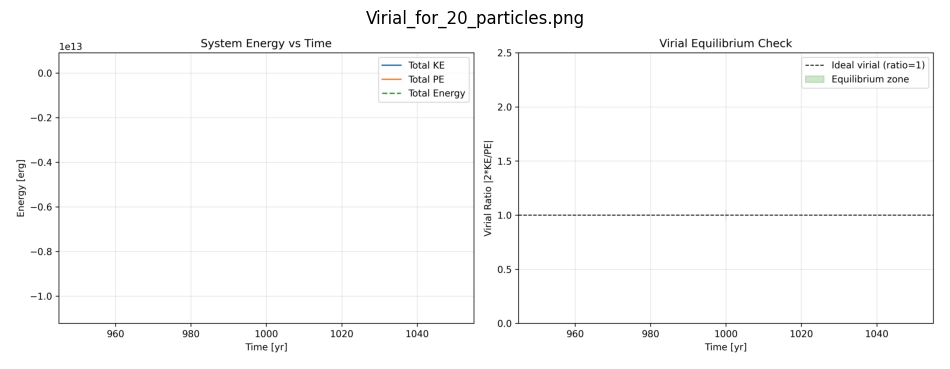

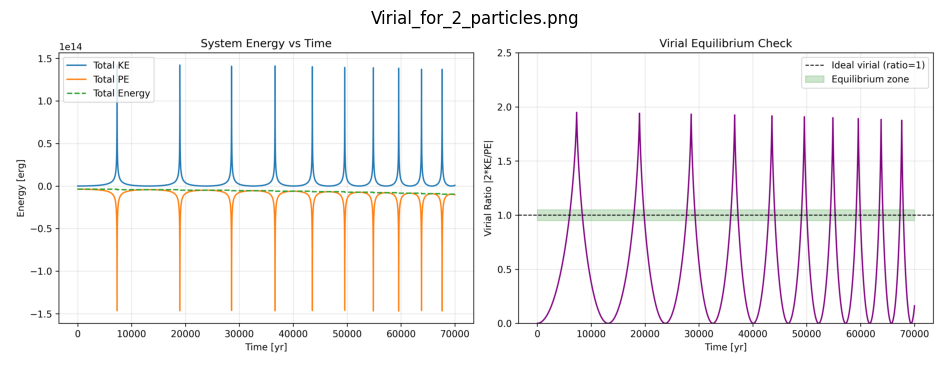

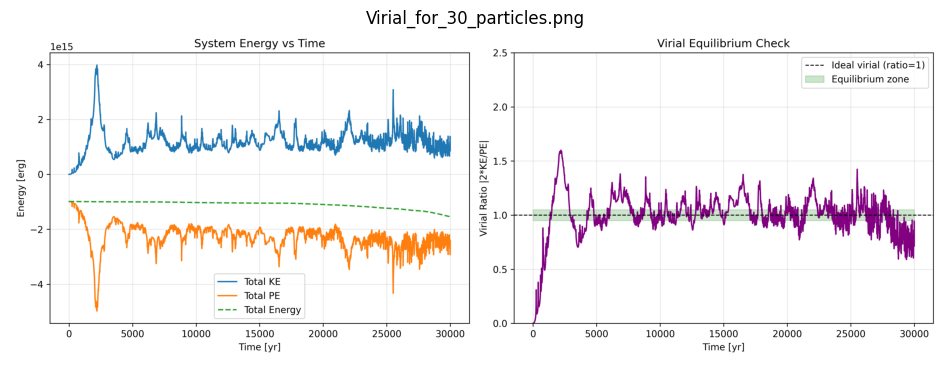

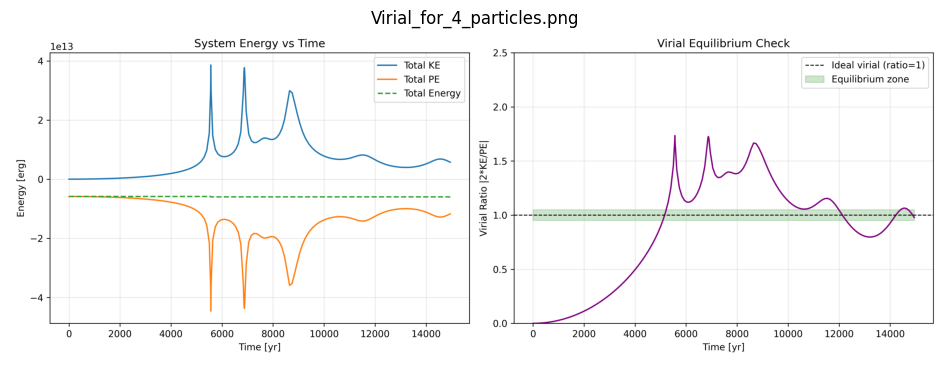

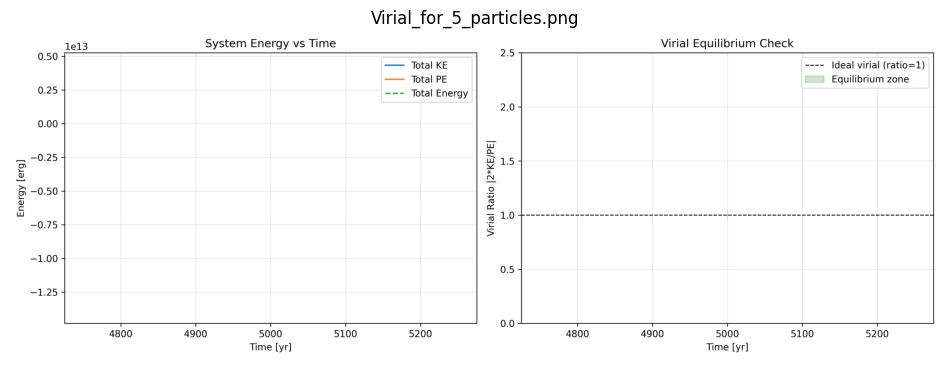

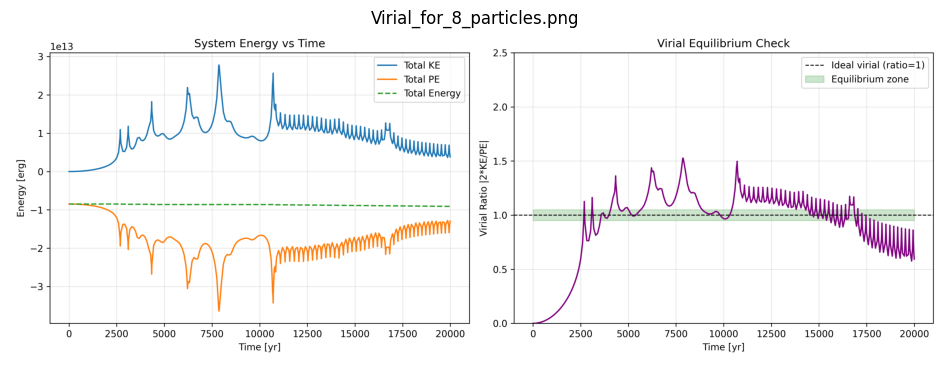

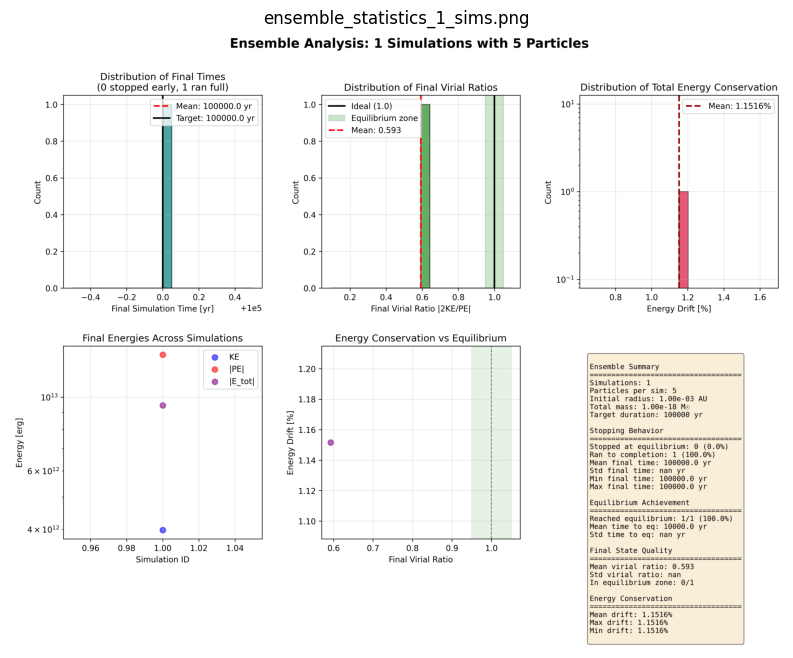

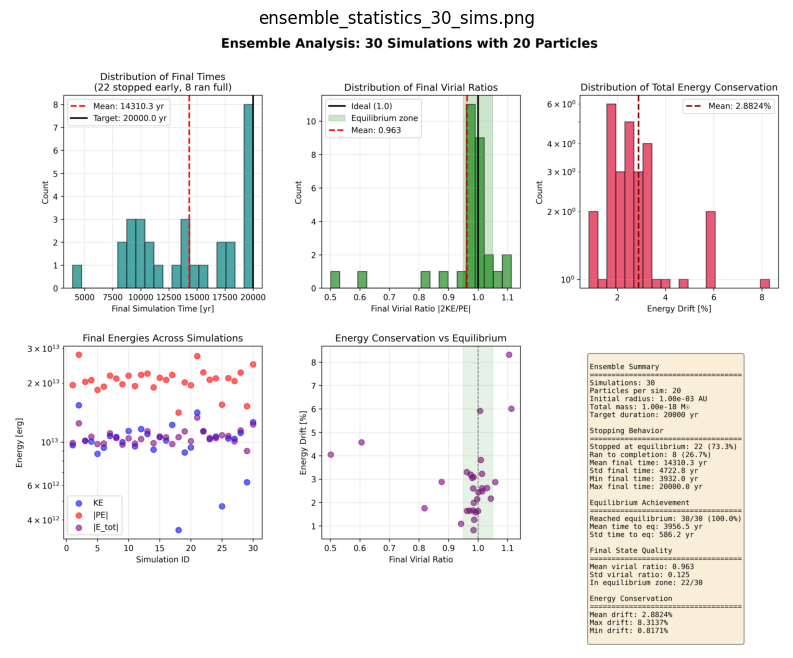

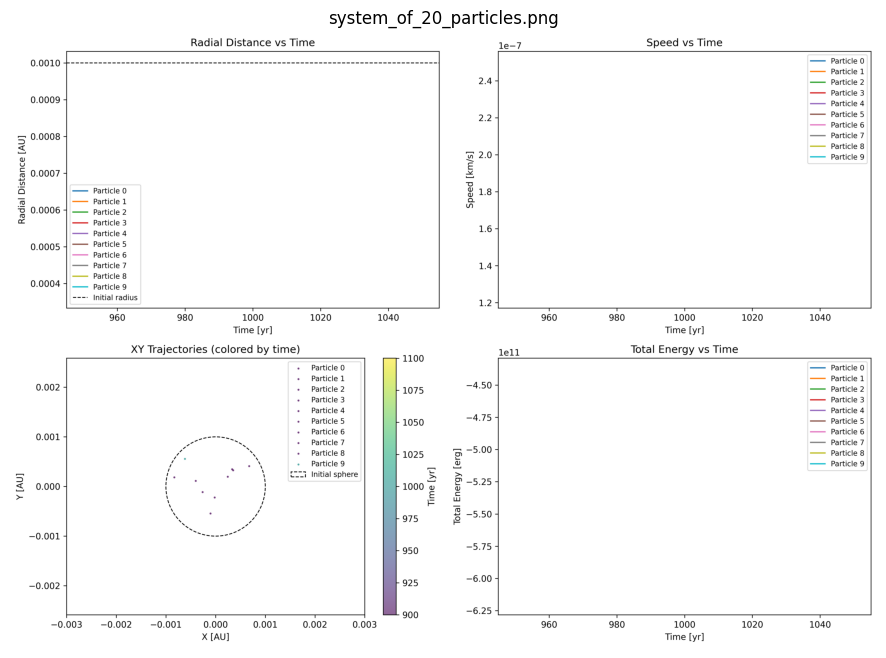

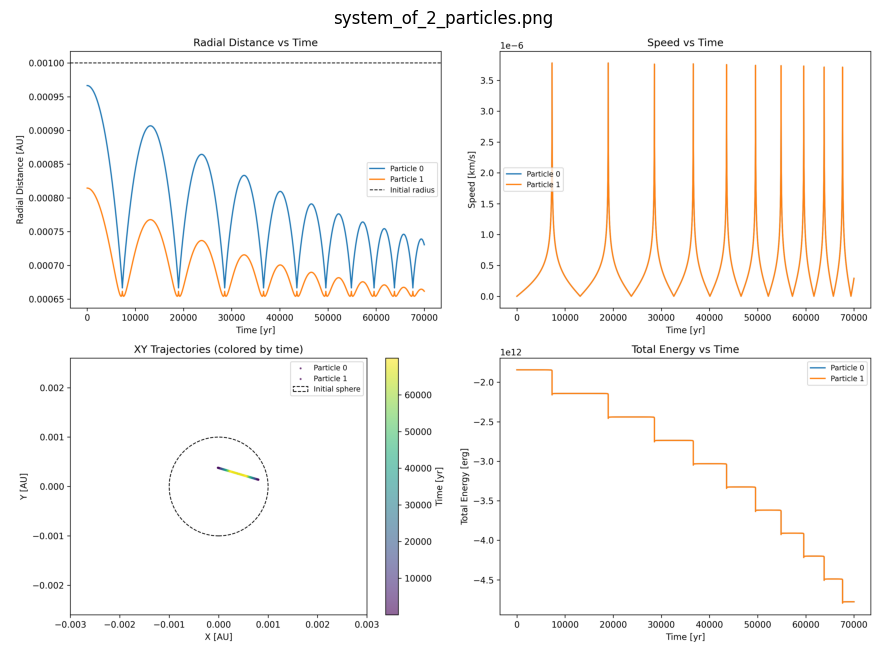

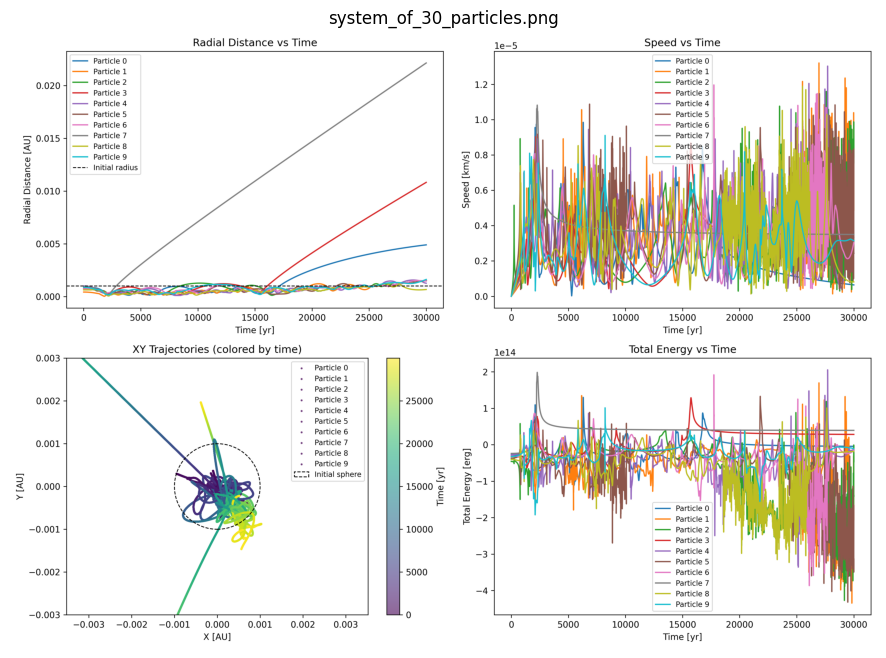

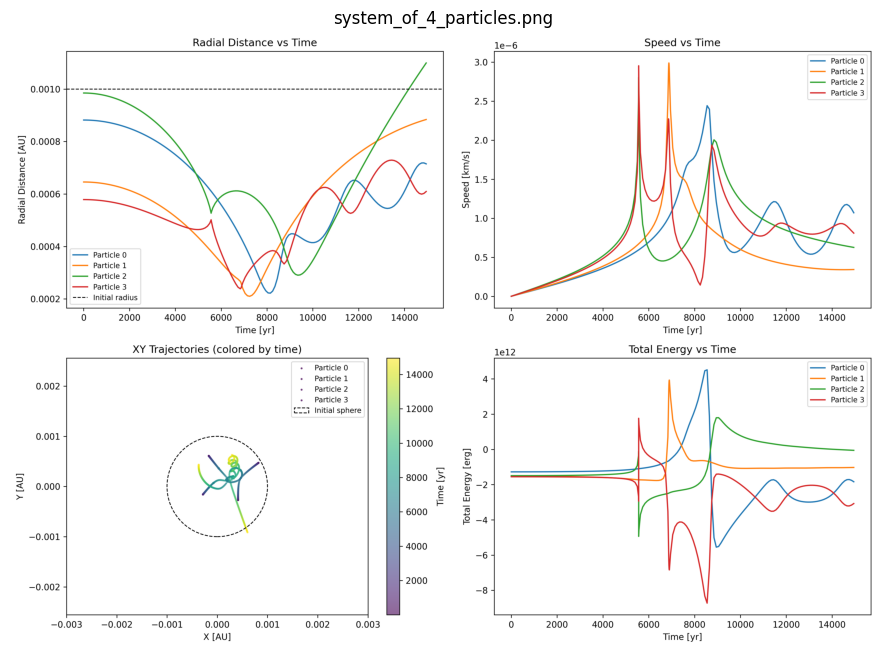

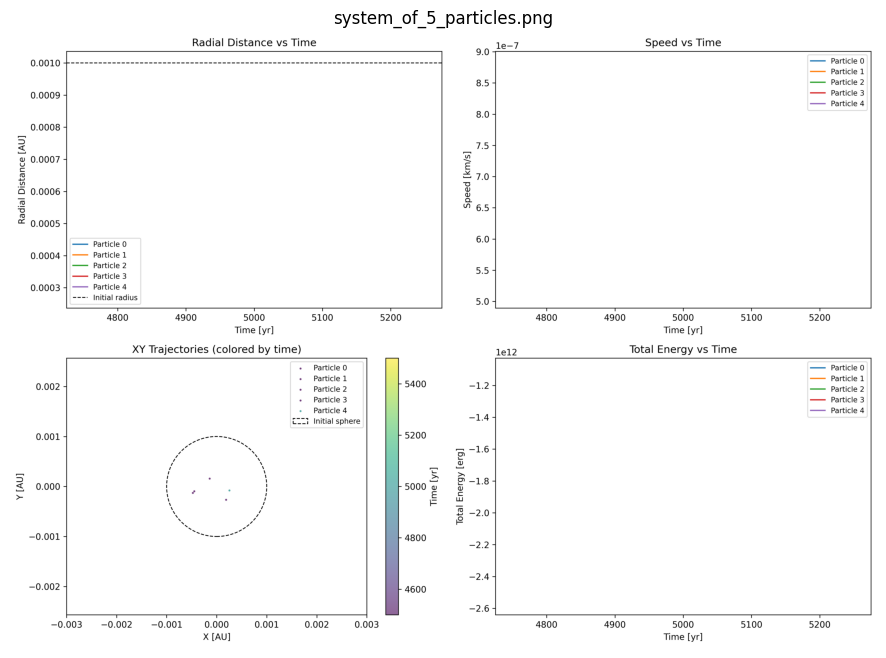

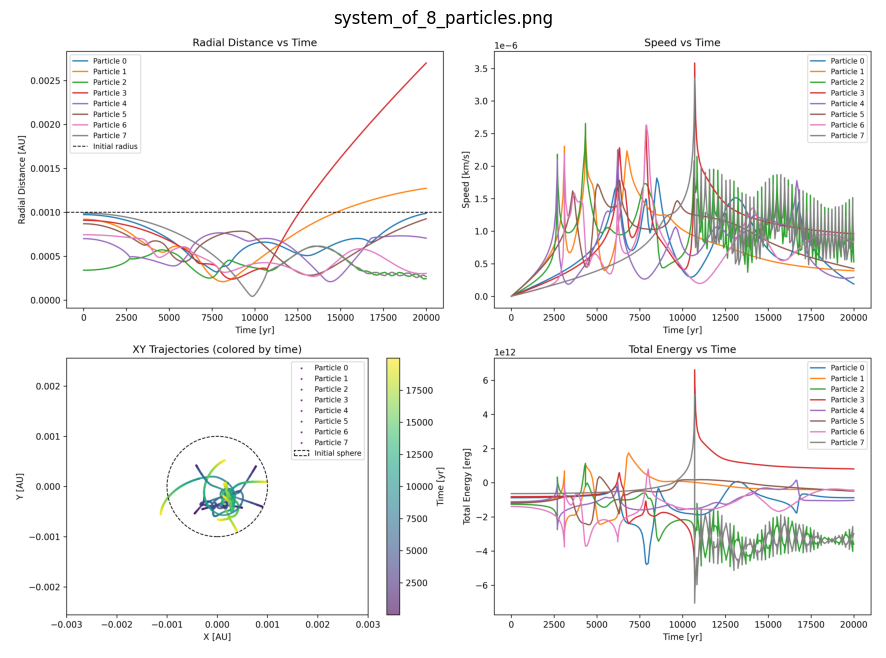

In [9]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
from ensemble_analysis import analyze_ensemble, get_project_root

project_root = Path(get_project_root())
fits_file = project_root / "nbody_simulations.fits"
plot_dir = project_root / "plots"

if fits_file.exists():
    analyze_ensemble(fits_filename=str(fits_file))

    if plot_dir.exists():
        for img_path in sorted(plot_dir.glob("*.png")):
            img = plt.imread(img_path)
            plt.figure(figsize=(12, 8))
            plt.imshow(img)
            plt.axis("off")
            plt.title(img_path.name)
            plt.show()
    else:
        print(f"Plot directory not found: {plot_dir}")
else:
    print(f"Data file {fits_file} not found. Did the simulation complete successfully?")